# FAME Database Inspection & Auditing Tools
This notebook provides a suite of tools to quickly audit, sample, and query the compiled FAME DuckDB database.

It uses `Ibis` to push computations directly to DuckDB, meaning queries execute in milliseconds and use almost zero Python memory.

In [ ]:
from pathlib import Path
from dataclasses import dataclass
import os
import sys
from dotenv import load_dotenv

# Add .env's PYTHONPATH to sys.path
load_dotenv(override=True)
PYTHONPATH = os.getenv("PYTHONPATH")
if PYTHONPATH is not None:
    if PYTHONPATH not in sys.path:
        print(f"Adding {PYTHONPATH} to sys.path")
        sys.path.append(PYTHONPATH)

# Define the structure clearly
@dataclass
class Dirs:
    data_dir: Path = None       # type: ignore
    output_dir: Path = None     # type: ignore
    input_dir: Path = None      # type: ignore
    db_path: Path = None         # type: ignore
dirs = Dirs()

try:
    from utils.f_0_dirs import get_data_dirs
    dirs = get_data_dirs()
    # raise ImportError("Testing ImportError for demonstration purposes") 

# For easy access purposes, if this script is run directly in a folder with the databases
# and without the dir import modules, then just set it to current_dir
except ImportError as e:
    print(f"ImportError: {e}")
    try:
        current_dir = Path(__file__).parent
    except NameError:
        current_dir = Path.cwd()
    dirs = Dirs(output_dir=current_dir, data_dir=current_dir, input_dir=current_dir)

for attr in dir(dirs):
    if attr.startswith('_'):
        continue
    if callable(getattr(dirs, attr)):
        continue
    print(f"{attr}: {getattr(dirs, attr)}")

Adding /mnt/c/Users/lazym/Documents/Code/dissertation/ to sys.path
❌ DATA_DIR path does not exist or is not a directory: /mnt/h/Other computers/My computer/fame_clean/1_FAME_raw_data/2025.07.30
data_dir: /mnt/h/Other computers/My computer/fame_clean/1_FAME_raw_data/2025.07.30
db_path: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output/fame_data.duckdb
input_dir: /mnt/c/Users/lazym/Documents/Code/dissertation/build/input
output_dir: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output
raw_data_dir: /mnt/h/Other computers/My computer/fame_clean/1_FAME_raw_data/2025.02
root_data_dir: /mnt/h/Other computers/My computer/fame_clean
root_dir: /mnt/c/Users/lazym/Documents/Code/dissertation
tmp_dir: /mnt/c/Users/lazym/Documents/Code/dissertation/build/tmp
work_dir: /mnt/c/Users/lazym/Documents/Code/dissertation/build/src


In [2]:
import pandas as pd
import ibis
import ibis.selectors as s

# 1. Setup paths
db_path = dirs.output_dir / "fame_data.duckdb"
if db_path != dirs.db_path:
    raise ValueError(f"db_path {db_path} does not match dirs.db_path {dirs.db_path}")

# 2. Connect to the database
con = ibis.duckdb.connect(str(db_path))

# 3. Configure Pandas display for easier reading
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 50)

print(f"✅ Successfully connected to: {db_path}")
print(con.list_tables())

✅ Successfully connected to: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output/fame_data.duckdb
['fame_fixed', 'fame_fixed_filtered', 'fame_yearly', 'fame_yearly_filtered', 'fame_yearly_kp', 'lars_fixed', 'lars_yearly', 'ref_ons_postcode', 'working_fixed', 'working_yearly']


In [3]:
import ibis

out_file = dirs.output_dir / "duckdb_tables.md"
con = ibis.duckdb.connect(str(dirs.output_dir / "fame_data.duckdb"))
interesting_tables = [
    "fame_fixed", "fame_yearly",
    "fame_fixed_filtered", "fame_yearly_filtered", "fame_yearly_kp",
    "lars_fixed", "lars_yearly",
    "working_fixed", "working_yearly"
]
existing_tables = con.list_tables()
print(f"Existing tables in the database: {existing_tables}")
# Intersection of 2 lists
intersection = [table for table in interesting_tables if table in existing_tables]

with open(out_file, "w") as f:
    f.write("# Tables in DuckDB database\n\n")
    for table in intersection:
        f.write(f"## {table}\n\n")
        f.write(f"### Number of rows: {con.table(table).count().execute():,}\n\n")
        f.write(f"### Schema:\n\n```\n{con.table(table).schema()}\n```\n\n")
        f.write(f"### Head of table:\n\n```\n{con.table(table).head().execute()}\n```\n\n")
print(f"✅ Successfully listed tables and their heads in: {out_file}")

Existing tables in the database: ['fame_fixed', 'fame_fixed_filtered', 'fame_yearly', 'fame_yearly_filtered', 'fame_yearly_kp', 'lars_fixed', 'lars_yearly', 'ref_ons_postcode', 'working_fixed', 'working_yearly']
✅ Successfully listed tables and their heads in: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output/duckdb_tables.md


### Output and drop other tables

In [4]:
# List all tables and their number of rows in the database that are not in the interesting_tables list
existing_tables = con.list_tables()
exclusion = set(existing_tables) - set(interesting_tables)
out_file = dirs.output_dir / "duckdb_other_tables.md"
print(f"Uninteresting tables: {exclusion}")
with open(out_file, "w") as f:
    f.write("# Other Tables in DuckDB database\n\n")
    for table in exclusion:
        f.write(f"## {table}\n\n")
        f.write(f"### Number of rows: {con.table(table).count().execute():,}\n\n")
        f.write(f"### Schema:\n\n```\n{con.table(table).schema()}\n```\n\n")
        f.write(f"### Head of table:\n\n```\n{con.table(table).head().execute()}\n```\n\n")
print(f"✅ Successfully listed other tables and their heads in: {out_file}")

Uninteresting tables: {'ref_ons_postcode'}
✅ Successfully listed other tables and their heads in: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output/duckdb_other_tables.md


In [5]:
run_this = False
if run_this == True:
    keep_tables = [] + interesting_tables
    # Try and drop all other tables in the database that are not in the keep_tables list

    # List the tables in exclusion, and then prompt the user to y/n confirm dropping those table names as a console input
    print(f"Tables to be dropped: {exclusion - set(keep_tables)}")
    user_input = input("Do you want to drop these tables? (y/n): ")
    if user_input.lower() != 'y':
        print("Aborting table drop operation.")
        raise SystemExit("Stopping execution after listing tables. Remove this line to continue with dropping tables.")
    for table_name in exclusion:
        if table_name in keep_tables:
            continue
        print(f"🗑️ Dropping table: {table_name} with {con.table(table_name).count().execute():,} rows")
        try:
            con.drop_table(table_name)
        except Exception as e:
            print(f"❌ Failed to drop table {table_name}: {e}")

## 1. High-Level Database Overview
Quickly check which tables exist in the database and their total row counts.

In [6]:
tables = con.list_tables()
print("📊 Database Tables Overview:\n" + "-"*30)

for table_name in tables:
    t = con.table(table_name)
    # Fast row counting pushed down to DuckDB
    row_count = t.count().execute()
    col_count = len(t.columns)
    print(f"[{table_name}]")
    print(f"   Rows: {row_count:,} | Columns: {col_count}")
print("-" * 30)

📊 Database Tables Overview:
------------------------------
[fame_fixed]
   Rows: 9,283,479 | Columns: 31
[fame_fixed_filtered]
   Rows: 152,379 | Columns: 31
[fame_yearly]
   Rows: 44,865,127 | Columns: 37
[fame_yearly_filtered]
   Rows: 1,128,490 | Columns: 37
[fame_yearly_kp]
   Rows: 1,128,490 | Columns: 37
[lars_fixed]
   Rows: 452,638 | Columns: 26
[lars_yearly]
   Rows: 2,378,089 | Columns: 35
[ref_ons_postcode]
   Rows: 2,726,477 | Columns: 3
[working_fixed]
   Rows: 152,379 | Columns: 11
[working_yearly]
   Rows: 1,128,490 | Columns: 8
------------------------------


## 2. Fast Random Sampling (Reservoir Sampling)
Extract a random subset of rows for visual inspection. We use DuckDB's native reservoir sampling (`USING SAMPLE X ROWS`) so it returns instantly, even on tables with millions of rows, without doing a full table scan.

In [7]:
target_table = "working_yearly"
sample_frac = 0.001  # Sample fraction for random sampling

# Native Ibis sampling using positional row count and seed parameter
table = con.table(target_table)
row_count = table.count().execute()
df_sample = table.sample(sample_frac, seed=12345).execute()

print(f"🎲 Random sample of {row_count:,} rows from '{target_table}':")
display(df_sample)

🎲 Random sample of 1,128,490 rows from 'working_yearly':


,registered_number,year,employees,average_wage,gva1,gva2,gva1_per_worker,gva2_per_worker
0,02263617,2006,323,62.198466,24023.799415,23906.681835,74.377088,74.014495
1,04698097,2006,48,20.554567,-760.188876,NaN,-15.837268,NaN
2,03421552,2006,532,21.436616,11602.003364,11929.591702,21.808277,22.424045
3,05202036,2006,17116,15.834574,412921.383378,404845.976892,24.124876,23.653072
4,03281115,2006,62,9.493154,2600.550982,2370.873996,41.944371,38.239903
...,...,...,...,...,...,...,...,...
1062,00592844,2024,85,41.238576,4005.388000,4486.574000,47.122212,52.783224
1063,02626708,2024,3074,10.947812,37023.362000,NaN,12.044034,NaN
1064,05965116,2024,1259,57.347101,428000.000000,230500.000000,339.952343,183.081811
1065,01738920,2024,64,125.470844,4873.958000,29622.977000,76.155594,462.859016


## 3. Specific Lookup

### Firm-specific (Search by Name or ID)
Find all fixed and derived attributes for a specific company using partial string matching (case-insensitive).

In [8]:
search_term = "TESCO"  # Can be a partial name or a Registered Number
table_fixed = con.table("fame_fixed")

# Filter where company_name contains the search term OR exactly matches registered_number
search_query = table_fixed.filter(
    table_fixed["company_name"].upper().contains(search_term.upper()) |
    (table_fixed["registered_number"] == search_term)
)

# Pull the top 5 matches
df_search_results = search_query.head(10).execute()

print(f"🔍 Top search results for '{search_term}':")
display(df_search_results[["registered_number", "company_name", "ro_address", "primary_trading_address"]])

🔍 Top search results for 'TESCO':


,registered_number,company_name,ro_address,primary_trading_address
0,12782679,LATESCO LIMITED,"12 Greendale Road, Nuneaton, Warwickshire, CV1...",NaN
1,03474627,TESCO QUEST LIMITED,"8 Salisbury Square, London, EC4Y 8BB",NaN
2,10645827,BITTESCOMBE MANOR ESTATE LTD,"Bittescombe Manor Upton, Taunton, Somerset, TA...",NaN
3,06353207,TESCO.EU.COM LIMITED,"5 Whitmore Crescent, Chelmsford, Essex, CM2 6YN","5 Whitmore Crescent, Chelmsford, Essex, CM2 6YN"
4,07374250,WHITESCOMPUTERSERVICES LIMITED,"89 The Mount, Ringwood, Hampshire, BH24 1XZ","89 The Mount, Ringwood, Hampshire, BH24 1XZ"
5,09308012,ESTATESCO LTD,"203 West Street, Fareham, Hampshire, PO16 0EN",NaN
6,05888955,TESCO AQUA (NOMINEE 1) LIMITED,"Tesco House Shire Park, Kestrel Way, Welwyn Ga...","Tesco House Shire Park, Kestrel Way, Welwyn Ga..."
7,05888959,TESCO AQUA (FINCO1) LIMITED,"1 More London Place, London, SE1 2AF",NaN
8,05888960,TESCO AQUA (NOMINEE 2) LIMITED,"Tesco House Shire Park, Kestrel Way, Welwyn Ga...","Tesco House Shire Park, Kestrel Way, Welwyn Ga..."
9,05888962,TESCO FUCHSIA (NOMINEE 1) LIMITED,"8 Salisbury Square, London, EC4Y 8BB",NaN


### Industry-specific (by 2-digit SIC or 6-digit
- 6-digit using primary_uk_sic_2007_code in fame_fixed

In [9]:
# ### Industry-specific (by 2-digit SIC or 6-digit
# - 6-digit using primary_uk_sic_2007_code in fame_fixed
import json
import ibis
import pandas as pd

# Read build/input/SIC_priorities.json
search_inds = []
search_table = "fame_fixed_filtered"
additional_tables = ["working_yearly"]

get_from_json = False
if get_from_json:
    with open(dirs.input_dir / "SIC_priorities.json", "r") as f:
        sic_priorities = json.load(f)
        search_inds = [entry.get("Division") for entry in sic_priorities if entry.get("Errored") == True]
else:
    search_inds = ["70", "74"]

# Ensure strings are properly formatted (e.g. padded with zeros) just in case
search_inds_str = [str(x).zfill(2) for x in search_inds if x is not None]
print(f"Searching for following SIC divisions individually: {search_inds_str}")

# Connect to the tables in the database
# TODO: search for industries without fame_derived
t_fixed = con.table(search_table)

# List to accumulate our row records
results = []

for ind in search_inds_str:
    # 1. Filter the fame_fixed table for the specific SIC division
    regex_pattern = rf'\b{ind}\b'
    filtered_fixed = t_fixed.filter(
        t_fixed.industry_codes.re_search(regex_pattern)
    )
    fixed_count = filtered_fixed.count().execute()

    # Append the counts for this specific division to our results list
    results_obj = {
        "SIC_Division": ind
    }
    results_obj[search_table] = fixed_count

    # 3. For every additional table, filter using a semi-join and count the matches
    for table_name in additional_tables:
        t_additional = con.table(table_name)
        additional_count = t_additional.semi_join(filtered_fixed, "registered_number").count().execute()
        results_obj[table_name] = additional_count

    results.append(results_obj)

# Output the results as a formatted table
output_table = pd.DataFrame(results)

print("📊 Matching Rows by Table for Each SIC Division:")
display(output_table) # use print(output_table) if you aren't in a Jupyter environment

Searching for following SIC divisions individually: ['70', '74']
📊 Matching Rows by Table for Each SIC Division:


,SIC_Division,fame_fixed_filtered,working_yearly
0,70,14004,93192
1,74,2758,19155


## 4. Time-Series Construction (Joining Fixed & Yearly)
Combine the static company metadata with its longitudinal financial performance. This demonstrates the relational integrity of the `registered_number` primary key.

In [10]:
# Pick a specific company ID to track over time
selected_ids = df_sample["registered_number"].head().tolist()

t_fixed = con.table("fame_fixed")
t_yearly = con.table("fame_yearly")

# 1. Filter both tables to the target ID
firm_fixed = t_fixed.filter(t_fixed["registered_number"].isin(selected_ids))
firm_yearly = t_yearly.filter(t_yearly["registered_number"].isin(selected_ids))

# 2. Left join yearly financials onto the fixed metadata
firm_history = firm_yearly.left_join(firm_fixed, "registered_number")

# 3. Select a curated subset of columns to display
comprehensive_view = firm_history.select(
    "registered_number",
    "company_name",
    "year",
    # Safely select financial columns if they exist in the DB
    s.contains("turnover"),
    s.contains("profit_loss_pretax"),
    s.contains("employees")
).order_by("year") # Order chronologically

display(comprehensive_view.execute())

,registered_number,company_name,year,turnover,profit_loss_pretax,profit_loss_pretax2,employees,remuneration_employees
0,03281115,BL EMBRACE LTD,2006,NaN,1062.931,1062.931,62.0,380.920
1,05202036,WH SMITH PLC,2006,1340000.000,44000.000,44000.000,17116.0,192000.000
2,02263617,ENCOMPASS DIGITAL MEDIA LIMITED,2006,23725.000,-1445.000,-1445.000,323.0,13664.000
3,04698097,MUSEUM OF BRITISH ROAD TRANSPORT TRUST (COVENT...,2006,NaN,69.037,69.037,48.0,694.413
4,03421552,EMPLOYMENT PLUS HOLDINGS LIMITED,2006,8307.081,-199.081,-199.081,532.0,7524.164
...,...,...,...,...,...,...,...,...
72,05202036,WH SMITH PLC,2023,1793000.000,110000.000,110000.000,14177.0,367000.000
73,02263617,ENCOMPASS DIGITAL MEDIA LIMITED,2023,NaN,NaN,NaN,NaN,NaN
74,03281115,BL EMBRACE LTD,2023,NaN,NaN,NaN,NaN,NaN
75,05202036,WH SMITH PLC,2024,1918000.000,106000.000,106000.000,13921.0,386000.000


## 5. Summary Statistics & Aggregations
Generate high-level analytical cuts (e.g., counting the number of records per year, or assessing data coverage).

In [11]:
t_yearly = con.table("fame_yearly")

# Aggregate the number of financial records available per year
# Print numbers of available records for every financial column
yearly_distribution = (
    t_yearly
    .group_by("year")
    .aggregate(
        turnover=t_yearly["turnover"].count(),
        pnl=t_yearly["profit_loss_pretax"].count(),
        employees=t_yearly["employees"].count(),
        tangibles=t_yearly["tangibles"].count(),
        t_lab=t_yearly["tangibles_land_and_buildings"].count(),
        t_land_free=t_yearly["tangibles_land_freehold"].count(),
        t_land_lease=t_yearly["tangibles_land_leasehold"].count(),
        fixed_other=t_yearly["fixed_other"].count(),
        intangibles=t_yearly["intangibles"].count(),
        fixed_total=t_yearly["fixed_total"].count(),
        liabilities=t_yearly["liabilities"].count(),
        t_assets=t_yearly["total_assets"].count(),
        liabilites_lt=t_yearly["liabilites_lt"].count(),
        cos=t_yearly["cos"].count(),
        dividends=t_yearly["dividends"].count(),
        r_and_d=t_yearly["r_and_d"].count(),
        renum=t_yearly["remuneration_employees"].count(),
        wages=t_yearly["wages"].count(),
        ss_cost=t_yearly["social_security_costs"].count(),
        pension_cost=t_yearly["pensions_costs"].count(),
        ebitda=t_yearly["ebitda"].count(),
        all=t_yearly.count()
    )
    .order_by(ibis.desc("year"))
)

print("📈 Data coverage by year:")
# Format table with commas for readability and display
count_table: pd.DataFrame = yearly_distribution.execute()
count_table_formatted = count_table.copy().reset_index(drop=True)
for col in count_table_formatted.columns:
    if col != "year":
        count_table_formatted[col] = count_table_formatted[col].apply(lambda x: f"{x:,}")
display(count_table_formatted)

📈 Data coverage by year:


,year,turnover,pnl,employees,tangibles,t_lab,t_land_free,t_land_lease,fixed_other,intangibles,fixed_total,liabilities,t_assets,liabilites_lt,cos,dividends,r_and_d,renum,wages,ss_cost,pension_cost,ebitda,all
0,2025,759,860,"8,735","7,782",431,306,140,"5,644",478,"10,916","12,206","18,063","5,970",1,0,0,0,0,0,0,2,"23,662"
1,2024,"87,248","98,126","1,278,115","993,775","98,455","80,144","22,311","685,755","59,488","1,199,578","1,454,312","1,796,835","776,575","35,793","12,710","1,327","51,970","38,616","32,033","33,235","100,458","1,981,608"
2,2023,"194,129","228,967","2,288,462","1,880,076","209,875","164,680","54,497","1,282,932","137,487","2,292,221","2,773,692","3,413,902","1,526,315","92,766","32,452","4,957","114,014","92,169","79,274","80,959","224,297","3,528,552"
3,2022,"192,850","228,319","2,237,681","1,838,108","206,455","160,718","55,359","1,257,407","138,225","2,233,739","2,709,182","3,333,356","1,504,295","91,786","31,186","4,933","111,055","89,145","77,405","78,771","223,253","3,442,519"
4,2021,"190,673","225,472","2,168,934","1,783,334","199,035","153,975","54,175","1,214,968","138,388","2,151,847","2,639,500","3,229,526","1,461,349","89,356","29,813","4,664","110,399","87,956","75,683","76,652","220,646","3,330,718"
5,2020,"192,145","225,077","2,070,377","1,707,243","196,249","152,776","52,812","1,165,875","137,839","2,036,234","2,549,355","3,073,513","1,218,218","89,437","30,639","4,696","108,421","92,686","74,936","74,983","220,176","3,167,684"
6,2019,"194,756","225,119","1,512,079","1,626,565","204,953","165,672","50,206","1,139,826","138,402","1,931,645","2,424,907","2,913,704","995,232","90,232","34,693","4,601","105,208","104,368","73,191","71,081","220,082","2,998,462"
7,2018,"197,953","227,983","1,252,970","1,566,977","205,504","166,575","50,002","1,074,368","141,327","1,848,785","2,309,065","2,773,457","940,907","93,524","38,252","4,600","106,056","105,951","72,526","69,111","223,702","2,848,099"
8,2017,"211,329","243,277","1,048,998","1,513,100","203,633","165,547","48,810","1,027,649","149,013","1,756,682","2,221,153","2,654,750","885,527","99,774","42,857","4,628","111,674","111,569","73,364","66,249","238,764","2,721,724"
9,2016,"195,732","218,672","535,221","1,448,753","97,043","72,752","32,402","1,284,240","191,618","1,685,343","2,102,045","2,509,869","769,259","99,740","48,756","3,597","101,439","101,271","75,797","61,962","213,829","2,566,936"


## 6. Exporting Queries to Excel
Any queried subset of data can be instantly dumped into an Excel file for offline review.

In [12]:
import pandas as pd
import ibis

approach = 'random' # first

# Dump a random sample of 500 rows from each table to a single .xlsx file in /tmp
row_count = 2000
out_file_raw = dirs.output_dir / "df_raw_sample.xlsx"
out_tables = ["fame_fixed_filtered", "fame_yearly_filtered", "fame_yearly_kp", "working_fixed", "working_yearly", "lars_yearly", "lars_fixed"]
exists_tables = con.list_tables()
intersection = set(out_tables).intersection(exists_tables)

# but we want to have 5 separate tabs in the same excel file, one for each table, with the table name as the tab name
con = ibis.duckdb.connect(str(dirs.db_path))
with pd.ExcelWriter(out_file_raw, engine='openpyxl') as writer:
    # df_raw_head.to_excel(writer, sheet_name='df_raw', index=False)
    for table in intersection:
        if approach == 'first':
            con.table(table).head(row_count).execute().to_excel(writer, sheet_name=table, index=False)
        elif approach == 'random':
            nb_rows = con.table(table).count().execute()
            fraction = row_count / nb_rows if nb_rows > row_count else 1.0
            df_table_rd = con.table(table).sample(fraction, seed=12345).execute()
            df_table_rd.to_excel(writer, sheet_name=table, index=False)
        
print(f"✅ Successfully dumped a random {row_count} rows of df_raw to: {out_file_raw}")

✅ Successfully dumped a random 2000 rows of df_raw to: /mnt/c/Users/lazym/Documents/Code/dissertation/build/output/df_raw_sample.xlsx


# 7. Industry counts in each of the tables
### [read] Count cells belong to certain industries
- Using the fame_derived system
- Remove rows belonging to a certain industry, as a 'fresh start' mechanism

❌ DATA_DIR path does not exist or is not a directory: /mnt/h/Other computers/My computer/fame_clean/1_FAME_raw_data/2025.07.30
📊 Industry Codes and Their Counts:
Industry Code: 01, Count: 950
Industry Code: 02, Count: 121
Industry Code: 03, Count: 88
Industry Code: 05, Count: 52
Industry Code: 06, Count: 289
Industry Code: 07, Count: 89
Industry Code: 08, Count: 356
Industry Code: 09, Count: 465
Industry Code: 10, Count: 2,102
Industry Code: 11, Count: 365
Industry Code: 12, Count: 25
Industry Code: 13, Count: 485
Industry Code: 14, Count: 359
Industry Code: 15, Count: 73
Industry Code: 16, Count: 456
Industry Code: 17, Count: 572
Industry Code: 18, Count: 906
Industry Code: 19, Count: 68
Industry Code: 20, Count: 1,117
Industry Code: 21, Count: 419
Industry Code: 22, Count: 1,320
Industry Code: 23, Count: 598
Industry Code: 24, Count: 527
Industry Code: 25, Count: 2,787
Industry Code: 26, Count: 1,420
Industry Code: 27, Count: 1,046
Industry Code: 28, Count: 1,784
Industry Code: 29, C

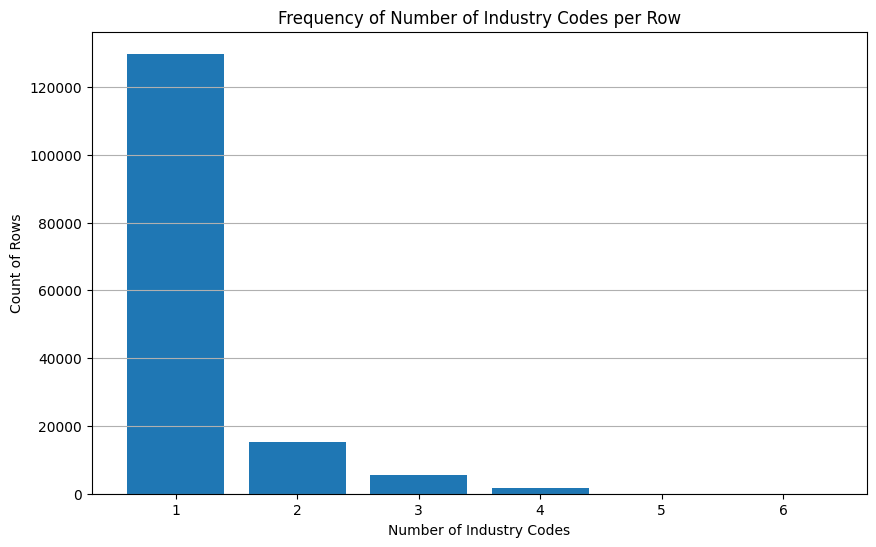

In [23]:
# connect to fame_derived and group by industry_codes
# count the number of rows belonging to each group (unique industry_codes)
# Sort the results in ascending order of industry_codes
# Output the result (as a table, with counts as the column)
import ibis
from ibis import _
import matplotlib.pyplot as plt
from utils.f_0_dirs import get_data_dirs

dirs = get_data_dirs()
con = ibis.duckdb.connect(str(dirs.db_path))
fame_derived = con.table("fame_fixed_filtered")

industry_counts = fame_derived.mutate(industry_codes_split=fame_derived.industry_codes.split(","))

# industry_codes are a comma-separated string of codes
# as each row could have multiple industry values
# Within SQL, separate them, and then count each unique value.
industry_counts_one = (
    fame_derived.mutate(industry_codes_split=fame_derived.industry_codes.split(","))
    .unnest("industry_codes_split")
    .group_by("industry_codes_split")
    .aggregate(count=_.count())
    .order_by("industry_codes_split")
)

# Additionally, we want to see how many rows have just 1 industry code, 2, 3 etc.
industry_counts_freq = (
    fame_derived.mutate(industry_codes_count=fame_derived.industry_codes.split(",").length())
    .group_by("industry_codes_count")
    .aggregate(count=_.count())
    .order_by("industry_codes_count")
)

# Execute and display the results
print("📊 Industry Codes and Their Counts:")
df_industry_counts = industry_counts_one.execute()
for index, row in df_industry_counts.iterrows():
    print(f"Industry Code: {row['industry_codes_split']}, Count: {row['count']:,}")

print("📊 Frequency of Number of Industry Codes per Row:")
df_industry_counts_freq = industry_counts_freq.execute()
for index, row in df_industry_counts_freq.iterrows():
    print(f"Number of Industry Codes: {row['industry_codes_count']}, Count: {row['count']:,}")
plt.figure(figsize=(10, 6))
plt.bar(df_industry_counts_freq['industry_codes_count'], df_industry_counts_freq['count'])
plt.xlabel('Number of Industry Codes')
plt.ylabel('Count of Rows')
plt.title('Frequency of Number of Industry Codes per Row')
plt.xticks(df_industry_counts_freq['industry_codes_count'])
plt.grid(axis='y')
plt.show()